# LLM Triage Inference — Gemini 2.0 Flash

Implements a `TriageModel` Protocol and `GeminiTriageModel` that produces
structured triage records from Godot GitHub issues. N-sample aggregation
yields pseudo-probabilities for coverage curves and ranking metrics,
enabling direct comparison with the TF-IDF baseline.

**Install:** `pip install google-genai python-dotenv`

In [1]:
from __future__ import annotations

import json
import time
import os
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Protocol, runtime_checkable, Any

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, hamming_loss

from scripts.schema.schema_validator import TriageSchemaValidator  # type: ignore

# Paths
PROJECT_ROOT = Path("../../..").resolve()  # adjust based on notebook location
DATA_DIR = Path("../data_collection/data/processed")
TRAIN_PATH = Path(DATA_DIR / "train.json")
VAL_PATH = Path(DATA_DIR / "val.json")
TEST_PATH = Path(DATA_DIR / "test.json")
OUTPUT_PATH = "results/gemini_flash_predictions.jsonl"
CHECKPOINT_PATH = "results/gemini_flash_checkpoint.jsonl"
SCHEMA_PATH = Path(PROJECT_ROOT / "src/schemas/triage_schema.json")

# ── Load environment ───────────────────────────────────────────────────
PROJECT_ROOT = Path("../../..").resolve()
load_dotenv(PROJECT_ROOT / ".env.local")
assert os.getenv("GEMINI_API_KEY"), "GEMINI_API_KEY not found — check .env.local"

## TriageModel Protocol

In [2]:
@runtime_checkable
class TriageModel(Protocol):
    """
    Interface for any triage model (TF-IDF, LLM, etc.).
    Any class with these methods satisfies the protocol.
    """

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame | None = None) -> None:
        """Train/prepare the model. No-op for zero-shot LLMs."""
        ...

    def predict(self, df: pd.DataFrame) -> list[dict]:
        """Return one triage record per row of df."""
        ...

    def predict_proba(self, df: pd.DataFrame) -> dict[str, np.ndarray]:
        """
        Return pseudo-probabilities per task.
        Keys are task names (e.g., "components", "issue_type").
        Values are (n_issues, n_labels) arrays.

        For TF-IDF: logistic regression probabilities.
        For LLM: label frequencies across N samples.
        """
        ...

    def get_run_metadata(self) -> dict:
        """Return model config for reproducibility logging."""
        ...

## Configuration

In [3]:
@dataclass(frozen=True)
class TaskConfig:
    """Describes one prediction task / label group."""
    name: str           # e.g., "components"
    label_col: str      # ground-truth column in the data (e.g., "topic")
    classes: list[str]  # allowed labels


@dataclass
class LLMRunConfig:
    """All configuration for an LLM triage run."""
    # Paths
    train_path: str = TRAIN_PATH
    val_path: str   = VAL_PATH
    test_path: str  = TEST_PATH
    vocab_path: str = Path(DATA_DIR / "label_vocab.json")
    schema_path: str = SCHEMA_PATH
    out_dir: str = "runs"

    # Model settings
    model_name: str = "gemini-2.5-flash-lite"
    temperature: float = 0.0
    n_samples: int = 1
    max_body_chars: int = 8000
    requests_per_minute: int = 14

    # Column mappings
    col_id: str = "id"
    col_title: str = "title"
    col_body: str = "body"

    # Aggregation threshold (for converting label frequencies to predictions)
    aggregation_threshold: float = 0.5

    # Repair settings
    max_repair_attempts: int = 1  # how many times to ask LLM to fix invalid output

    # Checkpoint
    checkpoint_dir: str = "results/checkpoints"

## GeminiTriageModel

Implements the `TriageModel` protocol:
- `fit()`: no-op for zero-shot (extendable for few-shot)
- `predict_proba()`: N-sample label frequencies (pseudo-probabilities)
- `predict()`: threshold the frequencies

Includes schema-aware **repair**: if the LLM output fails validation,
the errors are fed back to the model for correction before falling back.

In [4]:
class GeminiTriageModel:

    def __init__(self, config: LLMRunConfig, tasks: list[TaskConfig]):
        self.config = config
        self.tasks = tasks
        self._tasks_by_name = {t.name: t for t in tasks}
        self._label_sets = {t.name: set(t.classes) for t in tasks}

        # API client
        api_key = os.getenv("GEMINI_API_KEY")
        if not api_key:
            raise ValueError("GEMINI_API_KEY not found in environment.")
        self.client = genai.Client(api_key=api_key)

        # Schema validator (for repair loop)
        self.schema_validator = TriageSchemaValidator(config.schema_path)

        # System prompt
        self.system_prompt = self._build_system_prompt()

        # Caches
        self._raw_samples: dict[Any, list[dict]] = {}
        self._checkpoint_path = (
            Path(config.checkpoint_dir)
            / f"{config.model_name.replace('/', '_')}_n{config.n_samples}_samples.jsonl"
        )

        # Tracking
        self.stats = {
            "first_pass_valid": 0,
            "repaired": 0,
            "repair_failed": 0,
            "api_errors": 0,
            "content_blocked": 0,
            "total": 0,
        }

    # ── Prompt Construction ────────────────────────────────────────────

    def _build_system_prompt(self) -> str:
        components = self._tasks_by_name["components"].classes
        issue_types = self._tasks_by_name["issue_type"].classes
        platforms = self._tasks_by_name["platform"].classes
        impacts = self._tasks_by_name["impact"].classes

        return f"""You are an expert open-source issue triager for the Godot game engine.
        Given a GitHub issue (title + body), produce a JSON triage record that
        conforms EXACTLY to the schema below.

        ## Output Schema

        Return ONLY a valid JSON object — no markdown, no explanation.
        The object MUST have this exact structure:
        
        {{
          "schema_version": "1.0",
          "labels": {{
            "issue_type": [],
            "components": [],
            "platform": [],
            "impact": []
          }},
          "needs_human_triage": false,
          "meta": {{
            "source": "llm",
            "model": "{config.model_name}"
          }}
        }}
        
        ## Field Rules
        
        - "schema_version": always exactly "1.0"
        - "labels.issue_type": array with EXACTLY 0 or 1 item from {json.dumps(vocab["issue_type"])}
        - "labels.components": array with 1-3 items from {json.dumps(vocab["components"])}. This is the most important field.
        - "labels.platform": array with 0+ items from {json.dumps(vocab["platform"])}. Infer from OS mentions, stack traces. Empty [] if unclear.
        - "labels.impact": array with 0+ items from {json.dumps(vocab["impact"])}. Only include if clear textual evidence (e.g., "crash", "regression from 4.x"). Empty [] if none.
        - "needs_human_triage": true ONLY if you cannot confidently assign any component. If true, "labels.components" MUST be [].
        - "meta": always include "source": "llm" and "model": "{config.model_name}"
        - Do NOT include any fields not listed above (no "confidence", no "scores").
        - Return ONLY the JSON object."""

    def _build_user_prompt(self, title: str, body: str) -> str:
        if pd.isna(body):
            body = ""
        if pd.isna(title):
            title = ""
        if len(body) > self.config.max_body_chars:
            body = body[: self.config.max_body_chars] + "\n\n[... truncated ...]"
        return f"## Issue Title\n{title}\n\n## Issue Body\n{body}"

    # ── API Call with Repair ───────────────────────────────────────────

    def _call_api_raw(self, contents, retries: int = 2) -> str | None:
        """Low-level API call. Returns raw text or None."""
        for attempt in range(retries):
            try:
                response = self.client.models.generate_content(
                    model=self.config.model_name,
                    contents=contents,
                    config=types.GenerateContentConfig(
                        system_instruction=self.system_prompt,
                        response_mime_type="application/json",
                        temperature=self.config.temperature,
                    ),
                )
                if response.text:
                    return response.text.strip()
                else:
                    # Dig into why there's no text
                    print(f"      Empty response. Candidates: {response.candidates}")
                    if response.candidates:
                        for c in response.candidates:
                            print(f"      Finish reason: {c.finish_reason}")
                            if c.safety_ratings:
                                print(f"      Safety ratings: {c.safety_ratings}")
                    if hasattr(response, 'prompt_feedback') and response.prompt_feedback:
                        if response.prompt_feedback.block_reason:
                            print(f"      Blocked: {response.prompt_feedback.block_reason}")
                            self.stats["content_blocked"] += 1
                            return None

            except Exception as e:
                error_str = str(e)
                if "429" in error_str or "quota" in error_str.lower():
                    wait = 30 * (attempt + 1)
                    print(f"      Rate limited. Waiting {wait}s...")
                    time.sleep(wait)
                elif attempt < retries - 1:
                    time.sleep(5)
                else:
                    print(f"      API error after {retries} attempts: {error_str}")
                    self.stats["api_errors"] += 1
        return None

    def _call_with_repair(self, title: str, body: str) -> dict | None:
        """
        Call the LLM, validate output, and attempt repair if invalid.

        Flow:
          1. Send issue to LLM → get raw JSON
          2. Parse JSON, validate against schema
          3. If valid → return (first-pass success)
          4. If invalid → send errors back to LLM for repair
          5. If repair succeeds → return (repaired)
          6. If repair fails → clamp to vocab and return (best-effort)
        """
        self.stats["total"] += 1
        user_prompt = self._build_user_prompt(title, body)

        # ── First pass ──
        raw_text = self._call_api_raw(user_prompt)
        if raw_text is None:
            return None

        try:
            record = json.loads(raw_text)
        except json.JSONDecodeError:
            record = None

        if record is not None:
            ok, _, errors = self.schema_validator.validate_instance(record)
            if ok:
                self.stats["first_pass_valid"] += 1
                record["_schema_first_pass"] = True
                return record

            # ── Repair loop ──
            for repair_num in range(self.config.max_repair_attempts):
                error_summary = json.dumps(errors, indent=2)
                repair_prompt = (
                    f"Your previous output was invalid.\n\n"
                    f"Errors:\n{error_summary}\n\n"
                    f"Original output:\n{json.dumps(record, indent=2)}\n\n"
                    f"Fix the errors and return ONLY the corrected JSON."
                )

                repair_text = self._call_api_raw(repair_prompt)
                if repair_text is None:
                    continue

                try:
                    repaired = json.loads(repair_text)
                except json.JSONDecodeError:
                    continue

                ok, _, new_errors = self.schema_validator.validate_instance(repaired)
                if ok:
                    self.stats["repaired"] += 1
                    repaired["_schema_first_pass"] = False
                    repaired["_repair_attempt"] = repair_num + 1
                    return repaired

        # ── Fallback: clamp whatever we have ──
        self.stats["repair_failed"] += 1
        if record is not None:
            clamped = self._clamp_to_vocab(record)
            clamped["_schema_first_pass"] = False
            clamped["_repair_failed"] = True
            return clamped

        return None

    def _clamp_to_vocab(self, record: dict) -> dict:
        labels = record.get("labels", {})
        clamped_labels = {}

        it = labels.get("issue_type", [])
        if not isinstance(it, list):
            it = [it] if it in self._label_sets["issue_type"] else []
        clamped_labels["issue_type"] = [v for v in it if v in self._label_sets["issue_type"]]

        for field_name in ["components", "platform", "impact"]:
            vals = labels.get(field_name, [])
            if isinstance(vals, list):
                clamped_labels[field_name] = [v for v in vals if v in self._label_sets[field_name]]
            else:
                clamped_labels[field_name] = []

        nht = record.get("needs_human_triage", False)
        if not clamped_labels["components"]:
            nht = True

        return {
            "schema_version": "1.0",
            "labels": clamped_labels,
            "needs_human_triage": bool(nht),
            "meta": {"source": "llm", "model": self.config.model_name},
        }
    
    # ── N-Sample Generation ────────────────────────────────────────────

    def _generate_samples(self, df: pd.DataFrame) -> dict[Any, list[dict]]:
        """Generate N samples per issue with rate limiting and checkpointing."""
        cfg = self.config
        n = cfg.n_samples
        delay = 60.0 / cfg.requests_per_minute

        # Load checkpoint
        existing = self._load_checkpoint()
        self._raw_samples.update(existing)

        # Filter to issues needing more samples
        pending = []
        for _, row in df.iterrows():
            issue_id = row[cfg.col_id]
            have = len(self._raw_samples.get(issue_id, []))
            if have < n:
                pending.append((issue_id, row))

        print(f"Generating samples: {len(pending)} issues need work "
              f"({len(df) - len(pending)} already complete)")

        if not pending:
            return self._raw_samples

        self._checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

        total_calls = sum(n - len(self._raw_samples.get(iid, [])) for iid, _ in pending)
        call_num = 0

        for issue_id, row in pending:
            title = str(row[cfg.col_title])
            body = str(row[cfg.col_body])
            samples = list(self._raw_samples.get(issue_id, []))
            needed = n - len(samples)

            for _ in range(needed):
                call_num += 1
                print(f"  [{call_num}/{total_calls}] Issue {issue_id} "
                      f"(sample {len(samples)+1}/{n}): {title[:60]}...")

                result = self._call_with_repair(title, body)
                if result is not None:
                    samples.append(result)
                else:
                    print(f"    Failed — skipping this sample")

                time.sleep(delay)

            self._raw_samples[issue_id] = samples
            self._save_checkpoint_line(issue_id, samples)

        print(f"\nSample generation complete.")
        print(f"Stats: {json.dumps(self.stats, indent=2)}")
        return self._raw_samples

    # ── Checkpoint IO ──────────────────────────────────────────────────

    def _load_checkpoint(self) -> dict[Any, list[dict]]:
        loaded: dict[Any, list[dict]] = {}
        if self._checkpoint_path.exists():
            with open(self._checkpoint_path) as f:
                for line in f:
                    obj = json.loads(line)
                    loaded[obj["id"]] = obj["samples"]
            print(f"Checkpoint: loaded {len(loaded)} issues from {self._checkpoint_path}")
        return loaded

    def _save_checkpoint_line(self, issue_id: Any, samples: list[dict]) -> None:
        with open(self._checkpoint_path, "a") as f:
            f.write(json.dumps({"id": issue_id, "samples": samples}) + "\n")

    # ── Aggregation ────────────────────────────────────────────────────

    def _aggregate_proba(self, samples: list[dict], task: TaskConfig) -> np.ndarray:
        n = len(samples)
        if n == 0:
            return np.zeros(len(task.classes))
        freqs = np.zeros(len(task.classes))
        if task.name == "issue_type":
            for sample in samples:
                it_list = sample.get("labels", {}).get("issue_type", [])
                val = it_list[0] if it_list else ""
                if val in task.classes:
                    freqs[task.classes.index(val)] += 1
        else:
            for sample in samples:
                labels = sample.get("labels", {}).get(task.name, [])
                for j, cls in enumerate(task.classes):
                    if cls in labels:
                        freqs[j] += 1
        return freqs / n

    def _aggregate_prediction(self, proba: np.ndarray, task: TaskConfig) -> list[str] | str:
        """Categorical: argmax. Multi-label: threshold."""
        threshold = self.config.aggregation_threshold
        if task.name == "issue_type":
            return task.classes[int(np.argmax(proba))]
        else:
            return [task.classes[j] for j in range(len(task.classes)) if proba[j] >= threshold]

    # ── Protocol Methods ───────────────────────────────────────────────

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame | None = None) -> None:
        """No-op for zero-shot. Extendable for few-shot example selection."""
        print(f"fit(): zero-shot mode — no training needed.")
        print(f"  Train: {len(train_df)} issues (unused)  |  Val: {len(val_df) if val_df is not None else 0} issues (unused)")

    def predict_proba(self, df: pd.DataFrame) -> dict[str, np.ndarray]:
        """N samples per issue → per-label frequency matrices."""
        samples_by_id = self._generate_samples(df)

        result = {}
        for task in self.tasks:
            proba = np.zeros((len(df), len(task.classes)))
            for i, (_, row) in enumerate(df.iterrows()):
                issue_id = row[self.config.col_id]
                samples = samples_by_id.get(issue_id, [])
                proba[i] = self._aggregate_proba(samples, task)
            result[task.name] = proba

        return result

    def predict(self, df: pd.DataFrame) -> list[dict]:
        """Threshold pseudo-probabilities into triage records."""
        proba_dict = self.predict_proba(df)
        records = []

        for i, (_, row) in enumerate(df.iterrows()):
            record = {self.config.col_id: row[self.config.col_id]}

            for task in self.tasks:
                proba_row = proba_dict[task.name][i]
                record[task.name] = self._aggregate_prediction(proba_row, task)

            comps = record.get("components", [])
            record["needs_human_triage"] = len(comps) == 0

            comp_proba = proba_dict["components"][i]
            predicted_mask = comp_proba >= self.config.aggregation_threshold
            if predicted_mask.any():
                record["confidence"] = float(comp_proba[predicted_mask].mean())
            else:
                record["confidence"] = 0.0

            records.append(record)

        return records

    def get_run_metadata(self) -> dict:
        return {
            "model_type": "llm",
            "model_name": self.config.model_name,
            "temperature": self.config.temperature,
            "n_samples": self.config.n_samples,
            "aggregation_threshold": self.config.aggregation_threshold,
            "max_body_chars": self.config.max_body_chars,
            "max_repair_attempts": self.config.max_repair_attempts,
            "system_prompt": self.system_prompt,
            "label_vocab": {t.name: t.classes for t in self.tasks},
            "stats": self.stats,
            "timestamp": datetime.now().isoformat(),
        }
    
    def recompute_stats_from_samples(self):
        """Recompute schema stats from checkpointed raw samples."""
        self.stats = {k: 0 for k in self.stats}
        for issue_id, samples in self._raw_samples.items():
            for s in samples:
                self.stats["total"] += 1
                if s.get("_schema_first_pass", False):
                    self.stats["first_pass_valid"] += 1
                elif s.get("_repair_failed", False):
                    self.stats["repair_failed"] += 1
                elif s.get("_repair_attempt"):
                    self.stats["repaired"] += 1

## Evaluation Helpers

Model-agnostic — works with any model that satisfies the `TriageModel` protocol.

In [5]:
def evaluate_predictions(
    records: list[dict],
    df_true: pd.DataFrame,
    tasks: list[TaskConfig],
    col_id: str = "id",
) -> dict[str, dict]:
    """Micro-F1, macro-F1, Hamming loss, and coverage per task."""
    pred_by_id = {r[col_id]: r for r in records}
    results = {}

    for task in tasks:
        mlb = MultiLabelBinarizer(classes=task.classes)
        y_true_lists, y_pred_lists = [], []
        n_covered = 0

        for _, row in df_true.iterrows():
            issue_id = row[col_id]
            pred_rec = pred_by_id.get(issue_id, {})

            gt = row.get(task.label_col, [])
            if isinstance(gt, float) or gt is None:
                gt = []
            elif isinstance(gt, str):
                gt = [gt]
            y_true_lists.append(gt)

            pred = pred_rec.get(task.name, [])
            if isinstance(pred, float) or pred is None:
                pred = []
            elif isinstance(pred, str):
                pred = [pred]
            y_pred_lists.append(pred)

            if len(pred) > 0:
                n_covered += 1

        y_true = mlb.fit_transform(y_true_lists)
        y_pred = mlb.transform(y_pred_lists)
        n_total = len(df_true)

        results[task.name] = {
            "micro_f1": round(f1_score(y_true, y_pred, average="micro", zero_division=0), 4),
            "macro_f1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
            "hamming": round(hamming_loss(y_true, y_pred), 4),
            "coverage": round(n_covered / n_total, 4) if n_total > 0 else 0.0,
        }

    return results


def evaluate_ranking(
    proba_dict: dict[str, np.ndarray],
    df_true: pd.DataFrame,
    tasks: list[TaskConfig],
) -> dict[str, dict]:
    """Hit@5 and Recall@5 from pseudo-probability matrices."""
    results = {}

    for task in tasks:
        if task.name == "issue_type":
            continue

        mlb = MultiLabelBinarizer(classes=task.classes)
        y_true_lists = []
        for _, row in df_true.iterrows():
            gt = row.get(task.label_col, [])
            if isinstance(gt, float) or gt is None:
                gt = []
            elif isinstance(gt, str):
                gt = [gt]
            y_true_lists.append(gt)

        Y_true = mlb.fit_transform(y_true_lists)
        proba = proba_dict[task.name]
        k = min(5, proba.shape[1])

        top_k_idx = np.argsort(proba, axis=1)[:, -k:]
        hits, n_with = 0, 0
        recall_nums = []
        for i in range(len(Y_true)):
            n_true = Y_true[i].sum()
            if n_true == 0:
                continue
            n_with += 1
            if any(Y_true[i, j] == 1 for j in top_k_idx[i]):
                hits += 1
            recalled = sum(Y_true[i, j] for j in top_k_idx[i])
            recall_nums.append(recalled / n_true)

        results[task.name] = {
            "hit_at_5": round(hits / n_with, 4) if n_with else 0.0,
            "recall_at_5": round(float(np.mean(recall_nums)), 4) if recall_nums else 0.0,
        }

    return results


def coverage_accuracy_curve(
    proba: np.ndarray,
    df_true: pd.DataFrame,
    task: TaskConfig,
    grid: np.ndarray | None = None,
) -> list[dict]:
    """Sweep threshold → coverage-accuracy tradeoff curve."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 30)

    mlb = MultiLabelBinarizer(classes=task.classes)
    y_true_lists = []
    for _, row in df_true.iterrows():
        gt = row.get(task.label_col, [])
        if isinstance(gt, float) or gt is None:
            gt = []
        if isinstance(gt, str):
            gt = [gt]
        y_true_lists.append(gt)
    Y_true = mlb.fit_transform(y_true_lists)

    curve = []
    for t in grid:
        Y_pred = (proba >= t).astype(int)
        covered = Y_pred.sum(axis=1) > 0
        cov = covered.mean()
        if covered.sum() > 0:
            mf1 = f1_score(Y_true[covered], Y_pred[covered], average="micro", zero_division=0)
            avg_l = Y_pred[covered].sum(axis=1).mean()
        else:
            mf1, avg_l = 0.0, 0.0
        curve.append({"threshold": round(float(t), 4), "coverage": round(float(cov), 4),
                       "micro_f1_covered": round(float(mf1), 4), "avg_pred_labels": round(float(avg_l), 4)})
    return curve

## Save Artifacts

In [6]:
def save_run(config, model, predictions, proba_dict, metrics, ranking=None, comp_curve=None, schema_summary=None):
    """Save all run artifacts to a timestamped directory."""
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = Path(config.out_dir) / f"llm_{config.model_name.replace('/', '_')}_{ts}"
    run_dir.mkdir(parents=True, exist_ok=True)

    # Run metadata (includes full system prompt for reproducibility)
    metadata = model.get_run_metadata()
    metadata["metrics"] = metrics
    if ranking:
        metadata["ranking"] = ranking
    if schema_summary:
        metadata["schema_validation"] = schema_summary
    (run_dir / "run_metadata.json").write_text(
        json.dumps(metadata, indent=2, default=str), encoding="utf-8"
    )

    # Predictions
    with open(run_dir / "predictions.jsonl", "w") as f:
        for rec in predictions:
            f.write(json.dumps(rec, default=str) + "\n")

    # Probabilities
    for task_name, proba in proba_dict.items():
        np.save(run_dir / f"proba_{task_name}.npy", proba)

    # Coverage curve
    if comp_curve:
        (run_dir / "coverage_curve_components.json").write_text(
            json.dumps(comp_curve, indent=2), encoding="utf-8"
        )

    print(f"Run saved to {run_dir}")
    return run_dir

## Setup: Load Vocab, Data, and Model

In [7]:
config = LLMRunConfig(
    model_name="gemini-2.5-flash-lite",
    temperature=0.7,        # was 0.0 — need diversity for meaningful agreement
    n_samples=5,            # was 1
    requests_per_minute=1000,
    aggregation_threshold=0.5,
    max_repair_attempts=1,
)

with open(config.vocab_path) as f:
    vocab = json.load(f)

tasks = [
    TaskConfig(name="issue_type", label_col="issue_type", classes=vocab["issue_type"]),
    TaskConfig(name="components", label_col="topic",      classes=vocab["components"]),
    TaskConfig(name="platform",   label_col="platform",   classes=vocab["platform"]),
    TaskConfig(name="impact",     label_col="impact",     classes=vocab["impact"]),
]

for t in tasks:
    print(f"  {t.name}: {len(t.classes)} classes → GT col: {t.label_col}")

  issue_type: 4 classes → GT col: issue_type
  components: 18 classes → GT col: topic
  platform: 5 classes → GT col: platform
  impact: 4 classes → GT col: impact


In [8]:
def load_json_df(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        return pd.DataFrame(json.load(f))

df_train = load_json_df(config.train_path)
df_val   = load_json_df(config.val_path)
df_test  = load_json_df(config.test_path)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 12727 | Val: 1818 | Test: 3637


In [9]:
model = GeminiTriageModel(config, tasks)

assert isinstance(model, TriageModel), "GeminiTriageModel does not satisfy TriageModel protocol"
print("Protocol check passed.")

Protocol check passed.


In [10]:
model.fit(df_train, df_val)

fit(): zero-shot mode — no training needed.
  Train: 12727 issues (unused)  |  Val: 1818 issues (unused)


## Quick Test (5 issues)

Run on a small slice first to verify everything works end-to-end.

In [11]:
df_mini = df_test.head(5)
mini_predictions = model.predict(df_mini)

for rec in mini_predictions:
    print(json.dumps(rec, indent=2))

Checkpoint: loaded 10 issues from results\checkpoints\gemini-2.5-flash-lite_n5_samples.jsonl
Generating samples: 0 issues need work (5 already complete)
{
  "id": 3101623418,
  "issue_type": "bug",
  "components": [
    "editor",
    "gdscript"
  ],
  "platform": [
    "windows"
  ],
  "impact": [
    "usability"
  ],
  "needs_human_triage": false,
  "confidence": 1.0
}
{
  "id": 3101837170,
  "issue_type": "bug",
  "components": [
    "gdscript"
  ],
  "platform": [],
  "impact": [],
  "needs_human_triage": false,
  "confidence": 1.0
}
{
  "id": 3101947980,
  "issue_type": "bug",
  "components": [
    "3d",
    "core",
    "editor"
  ],
  "platform": [
    "windows"
  ],
  "impact": [
    "usability"
  ],
  "needs_human_triage": false,
  "confidence": 0.8666666666666667
}
{
  "id": 3102147499,
  "issue_type": "bug",
  "components": [
    "gui"
  ],
  "platform": [
    "linuxbsd"
  ],
  "impact": [],
  "needs_human_triage": false,
  "confidence": 1.0
}
{
  "id": 3102176698,
  "issue_ty

## Full Inference

Uncomment to run on the full test set. Checkpointing is built in — safe to interrupt and resume.

In [12]:
predictions = model.predict(df_test)
print(f"Generated {len(predictions)} predictions")
print(f"Stats: {json.dumps(model.stats, indent=2)}")

Checkpoint: loaded 10 issues from results\checkpoints\gemini-2.5-flash-lite_n5_samples.jsonl
Generating samples: 3627 issues need work (10 already complete)
  [1/18135] Issue 3103481336 (sample 1/5): Embedded game does not use project icon on Linux/X11 (fallba...
  [2/18135] Issue 3103481336 (sample 2/5): Embedded game does not use project icon on Linux/X11 (fallba...
  [3/18135] Issue 3103481336 (sample 3/5): Embedded game does not use project icon on Linux/X11 (fallba...
  [4/18135] Issue 3103481336 (sample 4/5): Embedded game does not use project icon on Linux/X11 (fallba...
  [5/18135] Issue 3103481336 (sample 5/5): Embedded game does not use project icon on Linux/X11 (fallba...
  [6/18135] Issue 3103655148 (sample 1/5): debug Android export via DAP doesn't work...
  [7/18135] Issue 3103655148 (sample 2/5): debug Android export via DAP doesn't work...
  [8/18135] Issue 3103655148 (sample 3/5): debug Android export via DAP doesn't work...
  [9/18135] Issue 3103655148 (sample 4/5): d

In [13]:
proba_dict = model.predict_proba(df_test)  # uses cached samples — no extra API calls
for name, arr in proba_dict.items():
    print(f"  {name}: shape {arr.shape}")

Checkpoint: loaded 3637 issues from results\checkpoints\gemini-2.5-flash-lite_n5_samples.jsonl
Generating samples: 12 issues need work (3625 already complete)
  [1/16] Issue 3154716490 (sample 5/5): Spurious early `finished` signal from AudioStreamPlayer3D...
  [2/16] Issue 3305229298 (sample 5/5): [4.5.beta5] Analog stick on SteamDeck skips buttons in UI na...
  [3/16] Issue 3315644914 (sample 5/5): `PhysicsDirectSpaceState*D` and `PhysicsDirectBodyState*D` a...
  [4/16] Issue 3368706103 (sample 5/5): DisplayServer get size, dpi, scale on Multiple monitor build...
  [5/16] Issue 3396137571 (sample 5/5): Godot freeze when editing color property in floating window ...
  [6/16] Issue 3494590558 (sample 5/5): RivaTuner causes the editor to crash randomly....
  [7/16] Issue 3547216457 (sample 5/5): [3.x] Switching to AssetLib main screen plugin crashes on 3....
  [8/16] Issue 3553128053 (sample 5/5): Missing `Default Texture Filter`  values...
  [9/16] Issue 3620073347 (sample 5/5): Cannot

## Schema Validation

In [14]:
# Recompute from checkpoint
model.recompute_stats_from_samples()

# Validate raw samples against schema
raw_records = [s for samples in model._raw_samples.values() for s in samples]
results = model.schema_validator.validate_many(raw_records)

n_total = len(raw_records)
n_first_pass = model.stats["first_pass_valid"]
clean_records = []
for r in raw_records:
    clean = {k: v for k, v in r.items() if not k.startswith("_")}
    clean_records.append(clean)

results = model.schema_validator.validate_many(clean_records)
n_post_repair_valid = sum(1 for r in results if r["ok"])

print(f"Total samples: {n_total}")
print(f"First-pass valid: {n_first_pass}/{n_total} ({n_first_pass/n_total*100:.1f}%)")
print(f"Post-repair valid: {n_post_repair_valid}/{n_total} ({n_post_repair_valid/n_total*100:.1f}%)")
print(f"Full stats: {json.dumps(model.stats, indent=2)}")

Total samples: 18180
First-pass valid: 16215/18180 (89.2%)
Post-repair valid: 18180/18180 (100.0%)
Full stats: {
  "first_pass_valid": 16215,
  "repaired": 1945,
  "repair_failed": 20,
  "api_errors": 0,
  "content_blocked": 0,
  "total": 18180
}


## Evaluation

In [15]:
metrics = evaluate_predictions(predictions, df_test, tasks, col_id=config.col_id)
for name, m in metrics.items():
    print(f"{name:>12}: micro-F1={m['micro_f1']:.4f}  macro-F1={m['macro_f1']:.4f}  "
          f"hamming={m['hamming']:.4f}  coverage={m['coverage']:.4f}")

  issue_type: micro-F1=0.8224  macro-F1=0.2767  hamming=0.0848  coverage=1.0000
  components: micro-F1=0.5911  macro-F1=0.5749  hamming=0.0833  coverage=0.9995
    platform: micro-F1=0.3114  macro-F1=0.4940  hamming=0.1569  coverage=0.9197
      impact: micro-F1=0.4498  macro-F1=0.5157  hamming=0.1754  coverage=0.7336


In [16]:
ranking = evaluate_ranking(proba_dict, df_test, tasks)
for name, r in ranking.items():
    print(f"{name:>12}: Hit@5={r['hit_at_5']:.4f}  Recall@5={r['recall_at_5']:.4f}")

  components: Hit@5=0.9459  Recall@5=0.8741
    platform: Hit@5=1.0000  Recall@5=1.0000
      impact: Hit@5=1.0000  Recall@5=1.0000


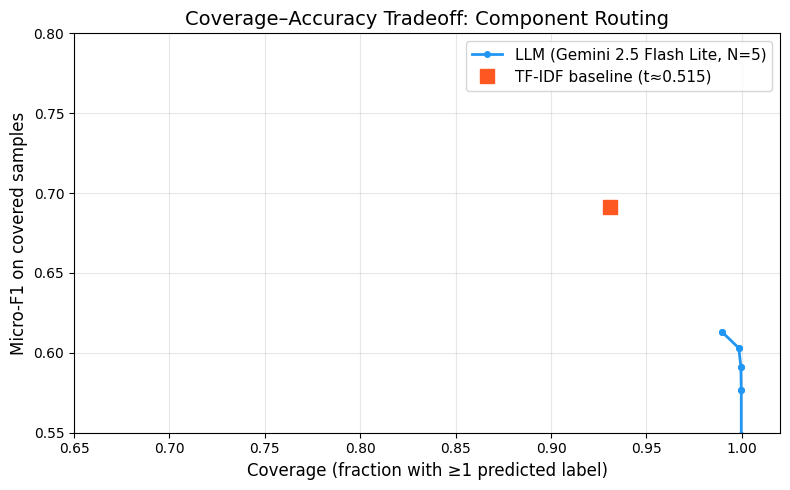

In [22]:
import matplotlib.pyplot as plt

# ── LLM coverage-accuracy curve ────────────────────────────────────────
comp_curve = coverage_accuracy_curve(
    proba_dict["components"], df_test, tasks[1],
    grid=np.array([0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]),
)

coverages = [p["coverage"] for p in comp_curve]
f1s = [p["micro_f1_covered"] for p in comp_curve]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(coverages, f1s, "o-", color="#2196F3", label="LLM (Gemini 2.5 Flash Lite, N=5)", linewidth=2, markersize=4)

# ── TF-IDF baseline point (from your milestone paper) ─────────────────
ax.plot(0.931, 0.691, "s", color="#FF5722", markersize=10, zorder=5, label="TF-IDF baseline (t≈0.515)")

# If you have the full TF-IDF curve data, load and plot it:
# tfidf_curve = json.load(open("path/to/tfidf_coverage_curve.json"))
# ax.plot([p["coverage"] for p in tfidf_curve],
#         [p["micro_f1_covered"] for p in tfidf_curve],
#         "^-", color="#FF5722", label="TF-IDF", linewidth=2, markersize=4)

ax.set_xlabel("Coverage (fraction with ≥1 predicted label)", fontsize=12)
ax.set_ylabel("Micro-F1 on covered samples", fontsize=12)
ax.set_title("Coverage–Accuracy Tradeoff: Component Routing", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.65, 1.02)
ax.set_ylim(0.55, 0.80)

plt.tight_layout()
plt.savefig("coverage_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Run

In [18]:
run_dir = save_run(
    config, model, predictions, proba_dict,
    metrics, ranking, comp_curve,
    schema_summary={"first_pass_valid": n_first_pass, "post_repair_valid": n_post_repair_valid, "total": n_total},
)

Run saved to runs\llm_gemini-2.5-flash-lite_20260324_195824
